In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 2.11
# Parameter study on the NONSTATIONARY 10-armed bandit

K = 10
STEPS = 200000

# Only these steps count toward performance
EVAL_START = 100000

# Increase this for smoother curves. Start with 200 while testing; try 1000-2000 for final results.
RUNS = 200
RANDOM_WALK_STD = 0.01

def epsilon_greedy(Q, epsilon, rng):
    """
    Vectorized epsilon-greedy selection. (Helper)
    Q shape: (runs, actions)
    """
    runs = Q.shape[0]

    # Random tie-breaking: adding tiny random noise avoids np.argmax always selecting the first action in a tie.
    greedy_actions = np.argmax(Q + rng.random(Q.shape) * 1e-12, axis=1)
    random_actions = rng.integers(0, K, size=runs)
    explore = rng.random(runs) < epsilon

    return np.where(explore, random_actions, greedy_actions)

# 1. EPSILON-GREEDY
def run_epsilon_greedy(
    epsilon,
    constant_alpha=None,
    seed=0
):

    rng = np.random.default_rng(seed)
    
    # q*(a) starts at zero, as specified in Exercise 2.5
    q_true = np.zeros((RUNS, K))
    Q = np.zeros((RUNS, K))
    counts = np.zeros((RUNS, K), dtype=np.int32)
    reward_sum = 0.0
    reward_count = 0

    rows = np.arange(RUNS)

    for t in range(STEPS):
        # Select action
        actions = epsilon_greedy(Q, epsilon, rng)

        # Reward: R_t ~ N(q*(A_t), 1)
        rewards = (q_true[rows, actions] + rng.normal(0, 1, RUNS))

        # Only evaluate final 100,000 steps
        if t >= EVAL_START:
            reward_sum += rewards.sum()
            reward_count += RUNS

        # Update Q
        counts[rows, actions] += 1
        if constant_alpha is None:
            # Sample-average update
            alpha = (1.0 / counts[rows, actions])
        else:
            # Constant step-size update
            alpha = constant_alpha
        Q[rows, actions] += (alpha * (rewards - Q[rows, actions]))

        # Nonstationarity: Every true action value performs a random walk; q* <- q* + N(0, 0.01^2)
        q_true += rng.normal(0, RANDOM_WALK_STD, size=(RUNS, K))

    return reward_sum / reward_count

In [ ]:
# 2. UCB
def run_ucb(c, seed=0):
    rng = np.random.default_rng(seed)
    q_true = np.zeros((RUNS, K))
    Q = np.zeros((RUNS, K))
    counts = np.zeros((RUNS, K), dtype=np.int32)

    reward_sum = 0.0
    reward_count = 0

    rows = np.arange(RUNS)
    for t in range(STEPS):
        # Try each action once first
        if t < K:
            actions = np.full(RUNS, t, dtype=int)
        else:
            bonus = (c * np.sqrt(np.log(t + 1) / counts))
            ucb = Q + bonus
            actions = np.argmax(ucb + rng.random(ucb.shape) * 1e-12, axis=1)

        rewards = (q_true[rows, actions] + rng.normal(0, 1, RUNS))
        
        if t >= EVAL_START:
            reward_sum += rewards.sum()
            reward_count += RUNS
        counts[rows, actions] += 1

        # Sample-average Q update
        alpha = (1.0 / counts[rows, actions])
        Q[rows, actions] += (alpha * (rewards - Q[rows, actions]))

        # Random walk
        q_true += rng.normal(0, RANDOM_WALK_STD, size=(RUNS, K))

    return reward_sum / reward_count

In [ ]:
# 3. GRADIENT BANDIT
def run_gradient_bandit(alpha, seed=0):
    rng = np.random.default_rng(seed)
    q_true = np.zeros((RUNS, K))
    H = np.zeros((RUNS, K))   # action preferences
    avg_reward = np.zeros(RUNS)   # avg reward baseline
    reward_sum = 0.0
    reward_count = 0

    rows = np.arange(RUNS)
    for t in range(STEPS):
        # Softmax
        H_shifted = (H - H.max(axis=1, keepdims=True))   #numerical stability 
        exp_H = np.exp(H_shifted)
        probs = (exp_H / exp_H.sum(axis=1, keepdims=True))
        cumulative = np.cumsum(probs, axis=1)   #sample from categorical dist
        r = rng.random(RUNS)
        actions = (cumulative < r[:, None]).sum(axis=1)

        # Reward
        rewards = (q_true[rows, actions] + rng.normal(0, 1, RUNS))
        if t >= EVAL_START:
            reward_sum += rewards.sum()
            reward_count += RUNS

        # Gradient update
        baseline = avg_reward.copy()
        advantage = (rewards - baseline)

        # For all actions: H(a) <- H(a) - alpha(R-baseline) pi(a)
        H -= (alpha * advantage[:, None] * probs)

        # For selected action add: alpha(R-baseline)
        H[rows, actions] += (alpha * advantage)

        # Sample-average reward baseline
        avg_reward += ((rewards - avg_reward) / (t + 1))

        # Random walk
        q_true += rng.normal(0, RANDOM_WALK_STD, size=(RUNS, K))

    return reward_sum / reward_count

In [ ]:
# 4. OPTIMISTIC INITIALIZATION
def run_optimistic(Q0, seed=0):
    rng = np.random.default_rng(seed)
    q_true = np.zeros((RUNS, K))

    # Optimistic Q initialization
    Q = np.full((RUNS, K), Q0, dtype=float)

    reward_sum = 0.0
    reward_count = 0

    rows = np.arange(RUNS)
    for t in range(STEPS):
        # Pure greedy action selection
        actions = np.argmax(Q + rng.random(Q.shape) * 1e-12, axis=1)
        rewards = (q_true[rows, actions] + rng.normal(0, 1, RUNS))
        if t >= EVAL_START:
            reward_sum += rewards.sum()
            reward_count += RUNS

        # Figure 2.6 uses alpha = 0.1
        Q[rows, actions] += (0.1 * (rewards - Q[rows, actions]))

        # Random walk
        q_true += rng.normal(0, RANDOM_WALK_STD, size=(RUNS, K))

    return reward_sum / reward_count

In [ ]:
# PARAMETER VALUES - Powers of two, as in Figure 2.6

epsilon_values = 2.0 ** np.arange(-7, -1)
# 1/128 ... 1/4

ucb_values = 2.0 ** np.arange(-4, 3)
# 1/16 ... 4

gradient_values = 2.0 ** np.arange(-5, 3)
# 1/32 ... 4

optimistic_values = 2.0 ** np.arange(-2, 3)
# 1/4 ... 4


In [ ]:
# RUN PARAMETER STUDY

sample_results = []
constant_results = []
ucb_results = []
gradient_results = []
optimistic_results = []

print("\nε-greedy — sample average")
for i, epsilon in enumerate(epsilon_values):
    print("epsilon =", epsilon)
    result = run_epsilon_greedy(epsilon, constant_alpha=None, seed=1000 + i)
    sample_results.append(result)

print("\nε-greedy — constant α = 0.1")
for i, epsilon in enumerate(epsilon_values):
    print("epsilon =", epsilon)
    result = run_epsilon_greedy(epsilon, constant_alpha=0.1, seed=2000 + i)
    constant_results.append(result)

print("\nUCB")
for i, c in enumerate(ucb_values):
    print("c =", c)
    result = run_ucb(c, seed=3000 + i)
    ucb_results.append(result)

print("\nGradient bandit")
for i, alpha in enumerate(gradient_values):
    print("alpha =", alpha)
    result = run_gradient_bandit(alpha, seed=4000 + i)
    gradient_results.append(result)

print("\nOptimistic initialization")
for i, Q0 in enumerate(optimistic_values):
    print("Q0 =", Q0)
    result = run_optimistic(Q0, seed=5000 + i)
    optimistic_results.append(result)


ε-greedy — sample average
epsilon = 0.0078125
epsilon = 0.015625
epsilon = 0.03125
epsilon = 0.0625
epsilon = 0.125
epsilon = 0.25

ε-greedy — constant α = 0.1
epsilon = 0.0078125
epsilon = 0.015625
epsilon = 0.03125
epsilon = 0.0625
epsilon = 0.125
epsilon = 0.25

UCB
c = 0.0625
c = 0.125
c = 0.25
c = 0.5
c = 1.0
c = 2.0
c = 4.0

Gradient bandit
alpha = 0.03125
alpha = 0.0625
alpha = 0.125
alpha = 0.25
alpha = 0.5
alpha = 1.0
alpha = 2.0
alpha = 4.0

Optimistic initialization
Q0 = 0.25
Q0 = 0.5
Q0 = 1.0
Q0 = 2.0
Q0 = 4.0


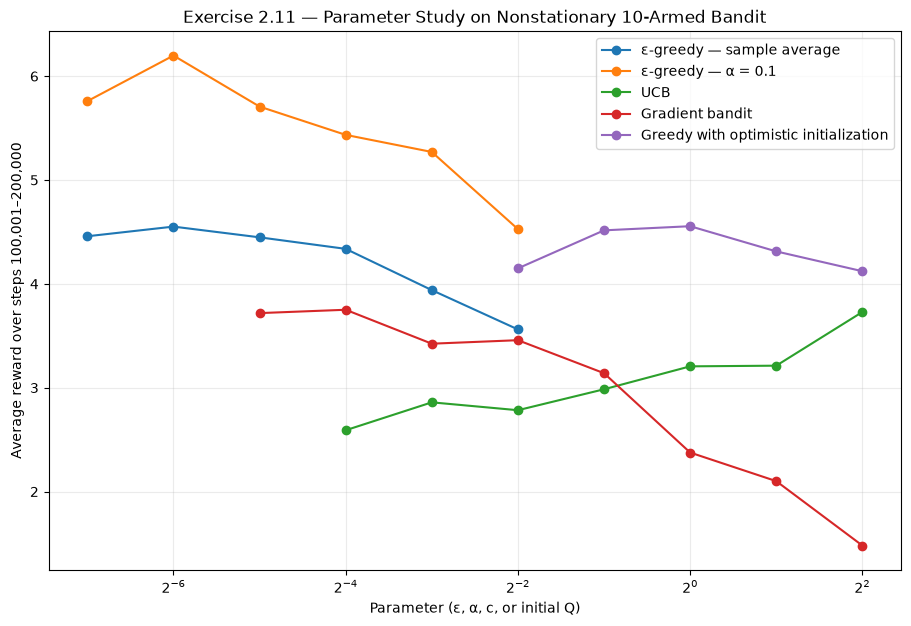

In [ ]:
plt.figure(figsize=(11, 7))
plt.semilogx(epsilon_values, sample_results, marker="o", base=2, label="ε-greedy — sample average")
plt.semilogx(epsilon_values, constant_results, marker="o", base=2, label="ε-greedy — α = 0.1")
plt.semilogx(ucb_values, ucb_results, marker="o", base=2, label="UCB")
plt.semilogx(gradient_values, gradient_results, marker="o", base=2, label="Gradient bandit")
plt.semilogx(optimistic_values, optimistic_results, marker="o", base=2, label="Greedy with optimistic initialization")
plt.xlabel("Parameter (ε, α, c, or initial Q)")
plt.ylabel("Average reward over steps 100,001–200,000")
plt.title("Exercise 2.11 — Parameter Study on Nonstationary 10-Armed Bandit")
plt.grid(alpha=0.25)
plt.legend()
plt.show()